## Appendix - A

In [1]:
# import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load data
location1 = '/Users/kristallee/Documents/DSC 680/Project 1/adult/adult.data.csv'
location2 = '/Users/kristallee/Documents/DSC 680/Project 1/adult/adult.test.csv'

df1 = pd.read_csv(location1)
df2= pd.read_csv(location2)

In [3]:
# remap target to binary values
df1['income'] = df1['income'].map({' <=50K':0,' >50K':1})
df2['income'] = df2['income'].map({' <=50K.':0,' >50K.':1})

In [4]:
# combine dataframes
df = pd.concat([df1, df2])

In [5]:
# df.shape

In [6]:
# remap sex to binary values
df['sex'] = df['sex'].map({' Female':0,' Male':1})

In [7]:
# create list of categorical columns
categorical = ['workclass','education','marital-status','occupation','relationships','race','native-country']

In [8]:
# create dummy variables for all categorical columns
dummies = pd.get_dummies(data = df, columns=categorical)

In [9]:
# define target column
target = dummies['income']

In [10]:
# define feature columns
features = dummies.drop('income', axis=1)

## Appendix - B

In [11]:
# import train and test split
from sklearn.model_selection import train_test_split

In [12]:
# split data into training and test sets 80/20 with all features
features_train, features_test, target_train, target_test = train_test_split(features, \
                                                                            target, test_size=0.2, random_state=0)

In [13]:
# import KNN and pipeline libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline, FeatureUnion

In [14]:
# set the min max scaler 
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0,1))
# knn classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=2, n_jobs=-1)
# pipeline
knnpipe = Pipeline([('min-max', minmax_scale), ('knn', knn)])

In [15]:
# fit model
knnpipe.fit(features_train, target_train)

Pipeline(steps=[('min-max', MinMaxScaler()),
                ('knn', KNeighborsClassifier(n_jobs=-1, n_neighbors=2))])

In [16]:
# knn predicitons 
pred_knn_full = knnpipe.predict(features_test)

In [17]:
# import accuracy
from sklearn.metrics import accuracy_score

In [18]:
acc_knn_full = accuracy_score(target_test, pred_knn_full)
#print("Accuracy - KNN model with all features: {0:.3f} ".format(acc_knn_full))

In [19]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif

In [20]:
# select 10 best features 
chi2_selector = SelectKBest(chi2, k=10)
features_kbest = chi2_selector.fit_transform(features, target)

In [21]:
# get top ten features list
mask = chi2_selector.get_support()
new_features = features.columns[mask]
feature_list = list(new_features)

In [22]:
# print("Ten selected features:",feature_list)

In [23]:
# features for only 10 selected 
features_top10 = features[feature_list]

In [24]:
# split training and test set from subset of 10 features from original features 
features_train_top10, features_test_top10, target_train_top10, target_test_top10 = train_test_split(features_top10, \
                                                                            target, test_size=0.2, random_state=0)

In [25]:
# KNN model with top 10 features
knn_pipe_top10 = knnpipe.fit(features_train_top10, target_train_top10)

In [26]:
# get the predicitions
pred_knn_top10 = knn_pipe_top10.predict(features_test_top10)

In [27]:
acc_knn_top10 = accuracy_score(target_test_top10, pred_knn_top10)
# print("Accuracy - KNN model with top 10 features: {0:.3f} ".format(acc_knn_top10))

In [28]:
# import Logistic Regression libraries and standard scaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [29]:
# establish scalar and log model
scaler = StandardScaler()
logistic_regression = LogisticRegression(random_state=0, multi_class="ovr")

In [30]:
# scale features
features_standardized = scaler.fit_transform(features)

In [31]:
# split test and train standardized features 80/20
features_train_std, features_test_std, target_train_std, target_test_std = train_test_split(features_standardized, \
                                                                            target, test_size=0.2, random_state=0)

In [32]:
# log model with standardized features
log_model = logistic_regression.fit(features_train_std, target_train_std)

In [33]:
# log predictions
pred_log = log_model.predict(features_test_std)

In [34]:
# Accuracy for logistic regression 
acc_log = accuracy_score(target_test_std, pred_log)
# print("Accuracy - Logistic Regression: {0:.3f} ".format(acc_log))

Accuracy - Logistic Regression: 0.852 


In [35]:
# import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [36]:
# establish Decision Tree Model
decisiontree = DecisionTreeClassifier(random_state=0)

In [37]:
# Train DT model with all features
dt_model_full = decisiontree.fit(features_train, target_train)

In [38]:
# DT model predicitions
pred_dt_full = dt_model_full.predict(features_test)

In [39]:
# find the accuracy for all features
acc_dt_full = accuracy_score(target_test, pred_dt_full)
# print("Accuracy - Decision Tree with all features: {0:.3f} ".format(acc_dt_full))

In [40]:
# DT model with top ten features
dt_model_top10 = decisiontree.fit(features_train_top10, target_train_top10)

In [41]:
# model using top 10 features 
pred_dt_top10 = dt_model_top10.predict(features_test_top10)

In [42]:
# find the accuracy of the default model
acc_dt_top10 = accuracy_score(target_test_top10, pred_dt_top10)
#print("Accuracy - Decision Tree with top 10 features: {0:.3f} ".format(acc_dt_top10))

## Appendix - C

In [43]:
# print accuracies of various model iterations
print("Model Accuracies:")
print("KNN - full : {0:.3f} ".format(acc_knn_full))
print("KNN - top 10 : {0:.3f} ".format(acc_knn_top10))
print("Log. Regression: {0:.3f} ".format(acc_log))
print("Decision Tree - full : {0:.3f} ".format(acc_dt_full))
print("Decision Tree - top 10 : {0:.3f} ".format(acc_dt_top10))

Model Accuracies:
KNN - full : 0.806 
KNN - top 10 : 0.821 
Log. Regression: 0.852 
Decision Tree - full : 0.821 
Decision Tree - top 10 : 0.809 


## Appendix - D

<Axes: ylabel='Feature'>

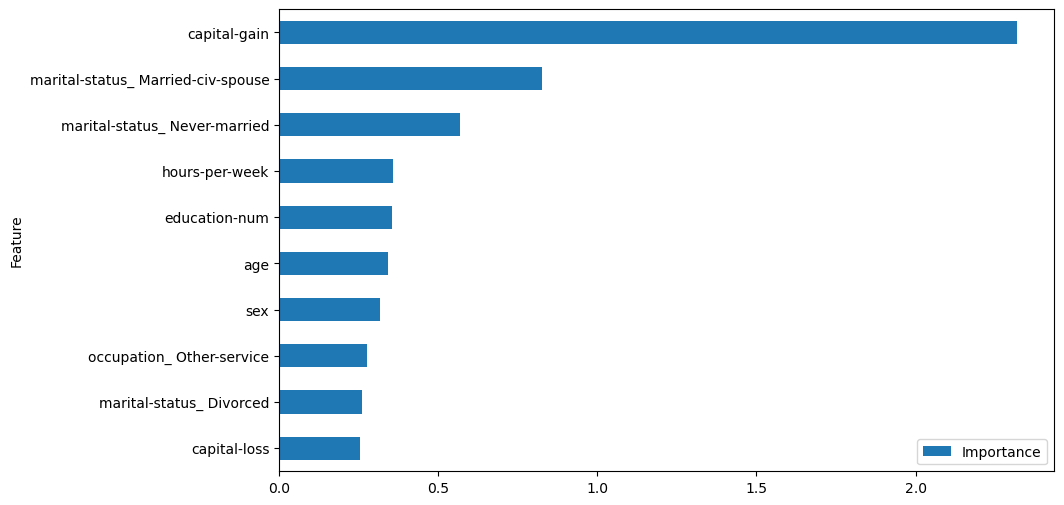

In [44]:
# get coefficients for log model
coefficients = log_model.coef_[0]

# plot top ten coefficients for Log Model
feature_importance = pd.DataFrame({'Feature': features_train.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
top10_features = feature_importance.sort_values('Importance', ascending=False)[:10]
top10_features.sort_values('Importance', ascending=True).plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

In [45]:
# marital status subset 
maritalstatus = df[['marital-status','income']]

<Axes: ylabel='marital-status'>

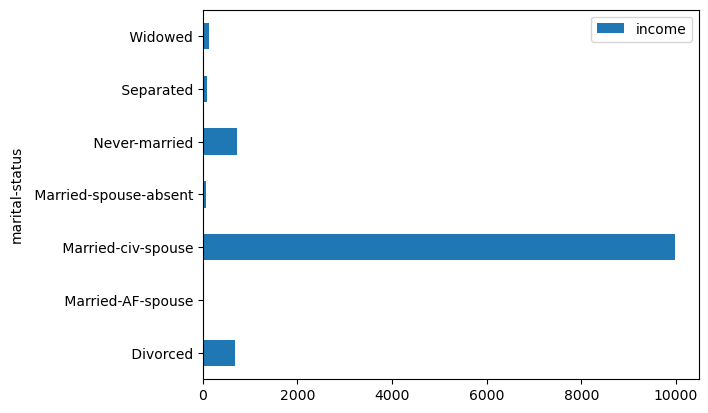

In [46]:
# plot instances of >50K for each marital status
maritalstatus.groupby('marital-status').sum().plot.barh()

In [47]:
# capital gains subset
capital_gains = df[['capital-gain','income']]
means = capital_gains.groupby('income').mean().values
means = [means[0][0],means[1][0]]
label_names = ['<=50K', '>50K']

[Text(0, 0, '147'), Text(0, 0, '4,042')]

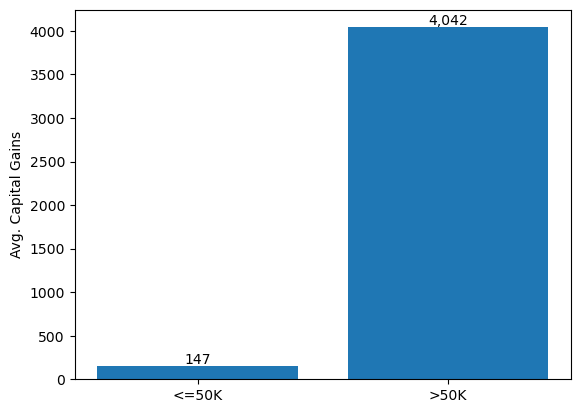

In [48]:
# plot of mean capital gains for target values
fig, ax = plt.subplots()
bar_container = ax.bar(label_names, means)
ax.set(ylabel='Avg. Capital Gains')
ax.bar_label(bar_container, fmt='{:,.0f}')